# AIHC Homework 4: NLP

### [Evan Jones](mailto:evan_jones@utexas.edu), UT ID:  `ej8387`

#### Extract Specific Disease Information from NoteEvents table


In [2]:
import sqlite_utils
import time
db = sqlite_utils.Database('../mimic3.db')
# "Laryngomalacia is a constriction in the larynx, common in newborns"
disease_name = "Laryngomalacia"
start = time.time()
results = db.query("SELECT * FROM noteevents WHERE LOWER(TEXT) LIKE '%{}%'".format(disease_name))
disease_notes = list(results)
elapsed = time.time() - start
print(f"Found {len(disease_notes)} entries containing {disease_name} in {elapsed:.2f}s")

Found 93 entries containing Laryngomalacia in 13.37s


In [3]:
# For demonstration purposes, let's choose a single note to display
import random
random.seed(42)
note_index = random.randint(0, len(disease_notes))
demo_note = disease_notes[note_index]["TEXT"]
print(
    f"Displaying note {note_index} out of {len(disease_notes)} notes: \n{demo_note}"
)


Displaying note 81 out of 93 notes: 
Attending Note
Day of life 13 PMA 42 [**5-16**]
in room air RR 30-50 upper airway congestion is present
no [**Month/Day (4) 62**] since last [**Month/Day (4) 23**]
had bronch yesterday which only showed larnygeal malacia
HR 110-140 BP 90/57 mean 68
weight 4525 up 100 grams on ad lib po feeds taking 70-100 cc po last night taking E 20 or BM 20 cal/oz
D stick 129
on prilosec, iron, and MTV
stable temp in open crib
passed car seat test
PKU sent today
passed hearing screen

IMP-infant with laryngomalacia now in stable condition
will d/c to home today (>30min)
Pedi appt for Monday
VNA will see in the next 2 days



### Helper Functions

In [4]:
from typing import TypeAlias
DBRow:TypeAlias = dict[str, str|int]

# `nlp_model` may be a Spacy or SciSpacy model
def build_corpus(nlp_model, notes: list[DBRow]) -> list[list[str]]:
    corpus: list[list[str]] = []
    for note in notes:
        tokens = nlp(note["TEXT"]).ents
        corpus.append(list([t.text for t in tokens]))
    return corpus


In [12]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def tsne_plot_pretrain(model, words, pre_trained=False, output_path:str|None=None):
    "Creates and TSNE model and plots it"
    labels = []
    tokens = []
    for word in words:
        if pre_trained:
            tokens.append(model[word])
        else:
            if word in model.wv:
                tokens.append(model.wv[word])
            else:
                continue
        labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(
        perplexity=30,
        early_exaggeration=12,
        n_components=2,
        init="pca",
        n_iter=1000,
        random_state=23,
    )
    new_values = tsne_model.fit_transform(tokens)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i], y[i])
        plt.annotate(
            labels[i],
            xy=(x[i], y[i]),
            xytext=(5, 2),
            textcoords="offset points",
            ha="right",
            va="bottom",
        )

    if output_path is not None:
        plt.savefig(output_path)
        print(f"Wrote plot image to {output_path}")
    plt.show()


In [13]:
def tsne_plot(model, words:list[str], output_path:str|None=None):
    "Creates a t-SNE model and plots it"
    labels = []
    tokens = []

    for word in words:
        if word in model.wv:
            tokens.append(model.wv[word])
            labels.append(word)
        else:
            print(f"Skipping '{word}' as it is not present in the model's vocabulary.")

    tsne_model = TSNE(
        perplexity=11,
        early_exaggeration=12,
        n_components=2,
        init="pca",
        n_iter=1000,
        random_state=23,
    )
    new_values = tsne_model.fit_transform(
        np.array(tokens)
    )  # Convert tokens to a NumPy array

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i], y[i])
        plt.annotate(
            labels[i],
            xy=(x[i], y[i]),
            xytext=(5, 2),
            textcoords="offset points",
            ha="right",
            va="bottom",
        )
    if output_path is not None:
        plt.savefig(output_path)
        print(f"Wrote plot image to {output_path}")    
    # Note that we write the file first,
    # then display, since plt.show() clears the figure    
    plt.show()


In [7]:
from typing import Callable
def show_html_table(rows: list[DBRow], column_fetchers: dict[str, Callable]):
    # Create the table
    table = PrettyTable()
    table.field_names = list(column_fetchers.keys())

    # skipped_numbers = 0
    for row in rows:
        row_vals = [column_fetchers[col_name](row) for col_name in column_fetchers]
        table.add_row(row_vals)

    # for ent in doc.ents:
    #     # Let's exclude numeric entities
    #     if ent.text[0].isdigit():
    #         skipped_numbers += 1
    #         continue
    #     table.add_row(
    #         [ent.text, f"{ent.start_char}:{ent.end_char}", ent.label_]
    #     )

    # Print the table
    # print(table)
    display(HTML(table.get_html_string()))

## Spacy NLP tools:


#### Spacy Entities

In [15]:
import spacy

# spacy Entities
print(f"Spacy Entities for demo note {note_index}:\n")
nlp = spacy.load("en_core_web_sm")
doc = nlp(demo_note)
skipped_numbers = 0

table_rows = [e for e in doc.ents if not e.text[0].isdigit()]
column_fetchers = {
    "Entity Text": lambda e:e.text,
    "Char Range": lambda e: f"{e.start_char}:{e.end_char}",
    "Label": lambda e: e.label_
}
show_html_table(table_rows, column_fetchers)


Spacy Entities for demo note 81:



/Users/jonese/Dropbox/Projects/UT_MSAI/spring_2025/ai_in_healthcare/hw4/.venv/lib/python3.12/site-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Entity Text,Char Range,Label
Month/Day,110:119,DATE
Month/Day,144:153,DATE
yesterday,175:184,DATE
malaciaHR,213:223,PERSON
lib po,280:286,PERSON
MTV,387:390,ORG
PKU,437:440,ORG
today,446:451,DATE
IMP,475:478,ORG
today,547:552,DATE


#### Spacy Word2Vec

In [9]:
# spacy Word2Vec
from gensim.models import Word2Vec

nlp = spacy.load("en_core_web_sm")
corpus = build_corpus(nlp, disease_notes)

# print(corpus)
print(f"Built corpus from {len(disease_notes)} notes about {disease_name}")

model1 = Word2Vec(corpus, min_count=1)
sub_word = "Stridor"
sub_explanation = "another name for Laryngomalacia"

print(f"\nSimilar words to '{sub_word}', {sub_explanation}:")

rows = model1.wv.similar_by_word(sub_word)
row_getters = {"Word": lambda r: r[0], "Similarity": lambda r: f"{r[1]: 0.3f}"}
show_html_table(rows, row_getters)


Built corpus from 93 notes about Laryngomalacia

Similar words to 'Stridor', another name for Laryngomalacia:


Word,Similarity
Diffuse,0.327
2189-11-23,0.321
Gastrointestinal,0.309
4p deletion,0.302
40s to 60s,0.294
nasal cannula,0.286
2182-6-10,0.285
68/31,0.283
ECHO,0.282
Discharge Medications,0.279


#### Spacy TsNE

Spacy tSNE plot for Laryngomalacia notes:



/Users/jonese/Dropbox/Projects/UT_MSAI/spring_2025/ai_in_healthcare/hw4/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Wrote plot image to assets/spacy_tsne_plot.png


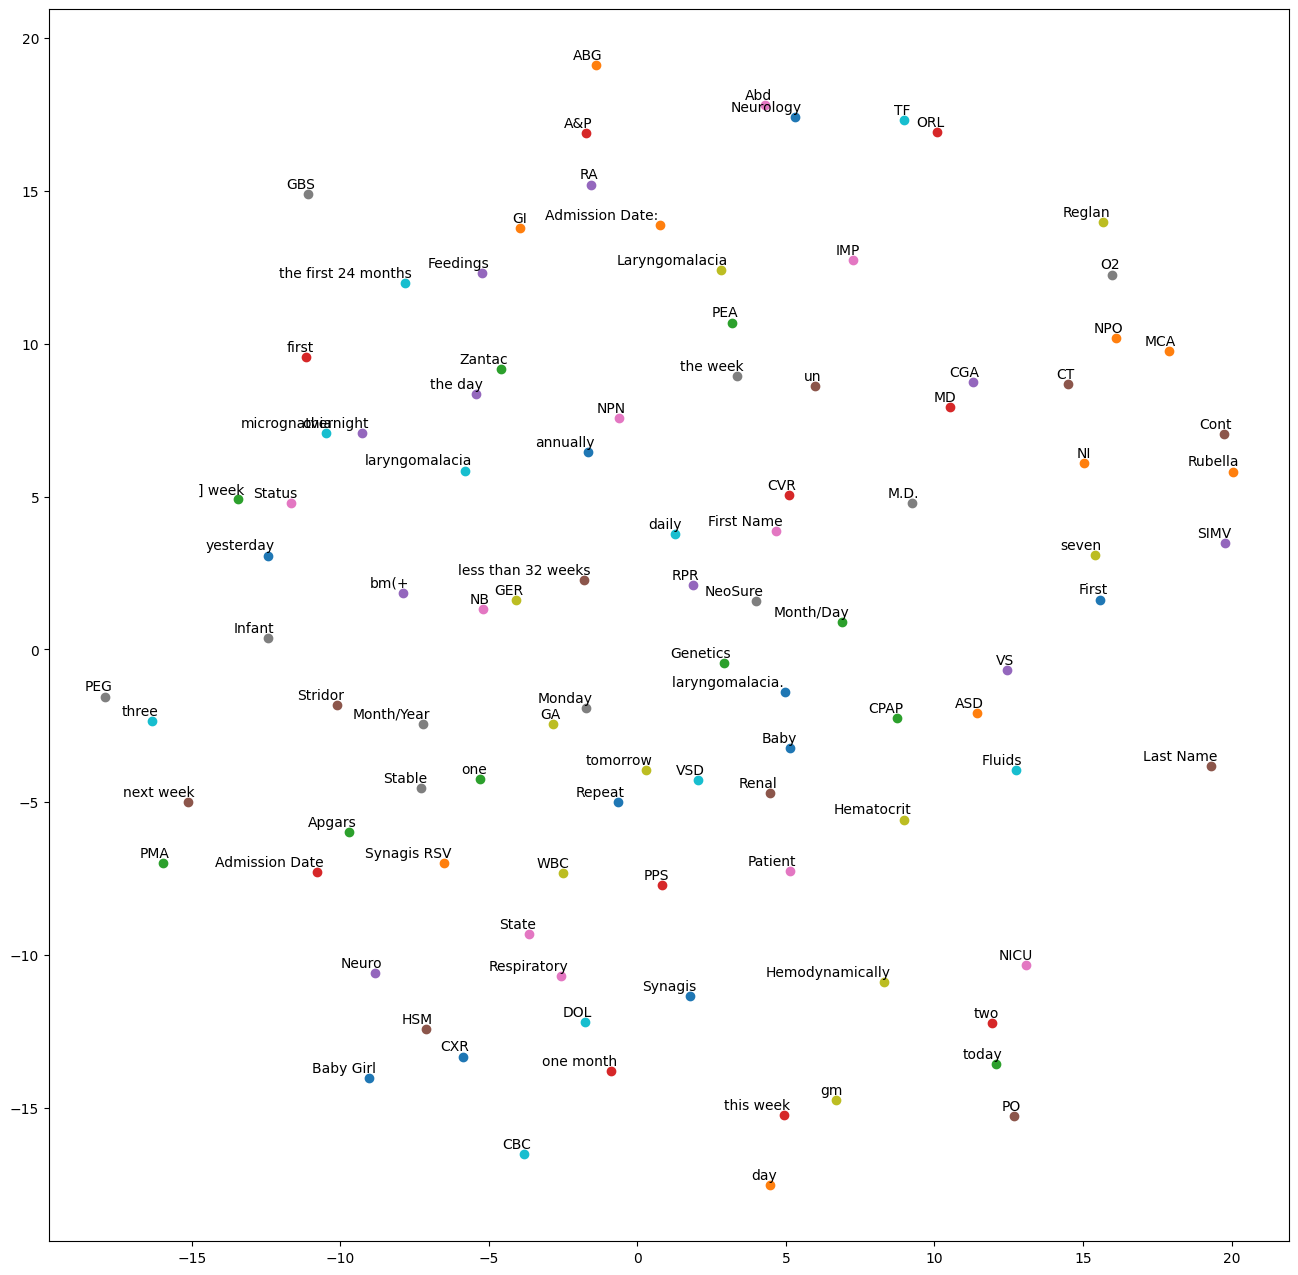

In [14]:
# spacy  tSNE plot
print(f"Spacy tSNE plot for {disease_name} notes:\n")

%matplotlib inline

vocabs = model1.wv.key_to_index.keys()
# remove any words that start with digits
v = [w for w in vocabs if not w[0].isdigit()]
new_v = np.array(list(v)[:100])
tsne_plot(model1, new_v, "assets/spacy_tsne_plot.png")

## SciSpacy NLP Tools:


#### SciSpacy Entities

In [16]:
# scispacy Entities
import en_core_sci_lg # A SciSpacy model
nlp = en_core_sci_lg.load()

# spacy Entities
print(f"SciSpacy Entities for demo note {note_index}:\n")
doc = nlp(demo_note)
skipped_numbers = 0

table_rows = [e for e in doc.ents if not e.text[0].isdigit()]
column_fetchers = {
    "Entity Text": lambda e: e.text,
    "Char Range": lambda e: f"{e.start_char}:{e.end_char}",
    "Label": lambda e: e.label_,
}
show_html_table(table_rows, column_fetchers)


/Users/jonese/Dropbox/Projects/UT_MSAI/spring_2025/ai_in_healthcare/hw4/.venv/lib/python3.12/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


SciSpacy Entities for demo note 81:



Entity Text,Char Range,Label
Attending,0:9,ENTITY
Note,10:14,ENTITY
Day,15:18,ENTITY
PMA,30:33,ENTITY
room air,51:59,ENTITY
RR,60:62,ENTITY
upper,69:74,ENTITY
airway congestion,75:92,ENTITY
bronch,168:174,ENTITY
yesterday,175:184,ENTITY


#### SciSpacy Word2Vec

In [19]:
# Scispacy Word2vec
print(f"SciSpacy Word2Vec for demo note {note_index}:\n")
nlp = spacy.load("en_ner_bc5cdr_md")


corpus = build_corpus(nlp, disease_notes)

print(f"Built corpus from {len(disease_notes)} notes about {disease_name}")

model2 = Word2Vec(corpus, min_count=1)
sub_word = "Stridor"
sub_explanation = "another name for Laryngomalacia"

print(f"\nSimilar words to '{sub_word}', {sub_explanation}:")

rows = model2.wv.similar_by_word(sub_word)
row_getters = {"Word": lambda r: r[0], "Similarity": lambda r: f"{r[1]: 0.3f}"}
show_html_table(rows, row_getters)

SciSpacy Word2Vec for demo note 81:

Built corpus from 93 notes about Laryngomalacia

Similar words to 'Stridor', another name for Laryngomalacia:


Word,Similarity
ventriculomegaly,0.273
esophogram,0.267
RhoGAM,0.232
dysgenesis of the corpus callosum,0.231
O2 sats,0.220
RA,0.217
cleft of thesoft palate,0.215
glaucoma,0.211
hypothermia,0.209
nystatin ointment,0.203


#### SciSpacy tSNE plot

SciSpacy tSNE plot for demo note 81:



/Users/jonese/Dropbox/Projects/UT_MSAI/spring_2025/ai_in_healthcare/hw4/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Wrote plot image to assets/scispacy_tsne_plot.png


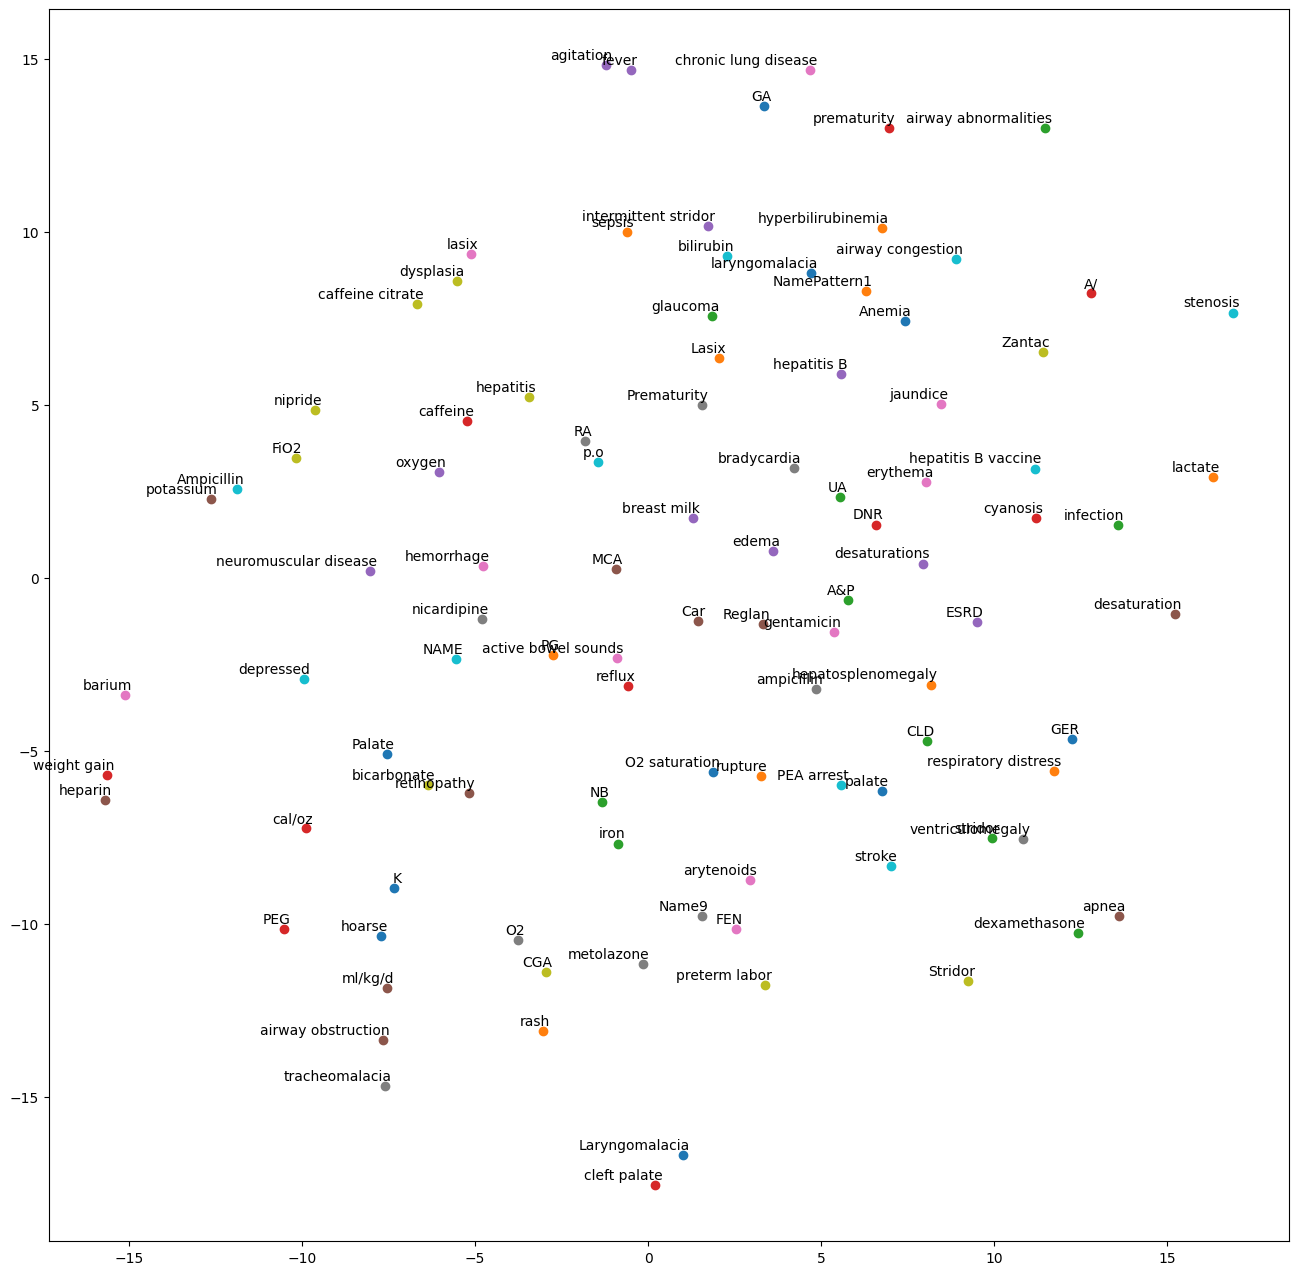

In [21]:
# scispacy tSNE plot
print(f"SciSpacy tSNE plot for demo note {note_index}:\n")


vocabs = model2.wv.key_to_index.keys()
# remove any words that start with digits
v = [w for w in vocabs if not w[0].isdigit()]
new_v = np.array(list(v)[:100])
tsne_plot(model1, new_v, "assets/scispacy_tsne_plot.png")